let's begin'''

In [27]:
import numpy as np

In [28]:
import pandas as pd

In [29]:
df = pd.read_csv("exams.csv")

In [30]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group D,some college,standard,completed,59,70,78
1,male,group D,associate's degree,standard,none,96,93,87
2,female,group D,some college,free/reduced,none,57,76,77
3,male,group B,some college,free/reduced,none,70,70,63
4,female,group D,associate's degree,standard,none,83,85,86
...,...,...,...,...,...,...,...,...
995,male,group C,some college,standard,none,77,77,71
996,male,group C,some college,standard,none,80,66,66
997,female,group A,high school,standard,completed,67,86,86
998,male,group E,high school,standard,none,80,72,62


In [31]:
df.info

<bound method DataFrame.info of      gender race/ethnicity parental level of education         lunch  \
0    female        group D                some college      standard   
1      male        group D          associate's degree      standard   
2    female        group D                some college  free/reduced   
3      male        group B                some college  free/reduced   
4    female        group D          associate's degree      standard   
..      ...            ...                         ...           ...   
995    male        group C                some college      standard   
996    male        group C                some college      standard   
997  female        group A                 high school      standard   
998    male        group E                 high school      standard   
999    male        group D                 high school      standard   

    test preparation course  math score  reading score  writing score  
0                 completed    

In [32]:
df.describe()

,math score,reading score,writing score
count,1000.000000,1000.000000,1000.000000
mean,67.810000,70.382000,69.140000
std,15.250196,14.107413,15.025917
min,15.000000,25.000000,15.000000
25%,58.000000,61.000000,59.000000
50%,68.000000,70.500000,70.000000
75%,79.250000,80.000000,80.000000
max,100.000000,100.000000,100.000000


In [33]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
import matplotlib.pyplot as plt

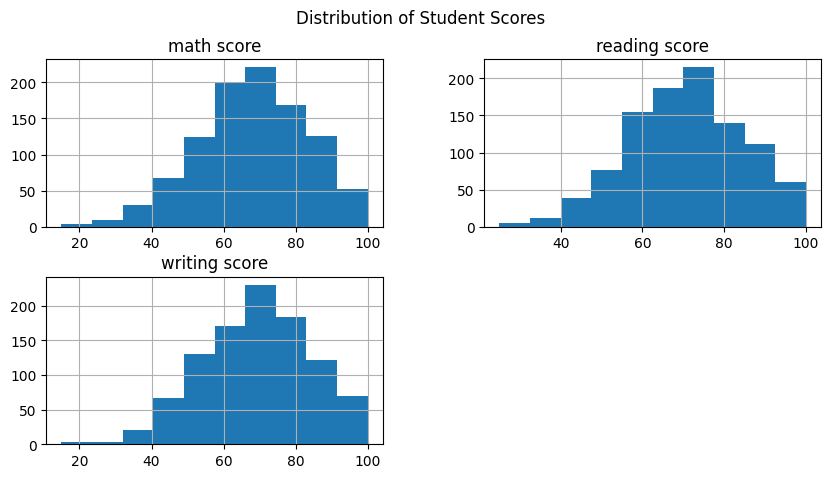

In [36]:
df[['math score', 'reading score', 'writing score']].hist(figsize=(10,5))

plt.suptitle("Distribution of Student Scores")
plt.show()

In [37]:
correlation = df[['math score', 'reading score', 'writing score']].corr()

print(correlation)

               math score  reading score  writing score
math score       1.000000       0.811767       0.790055
reading score    0.811767       1.000000       0.948909
writing score    0.790055       0.948909       1.000000


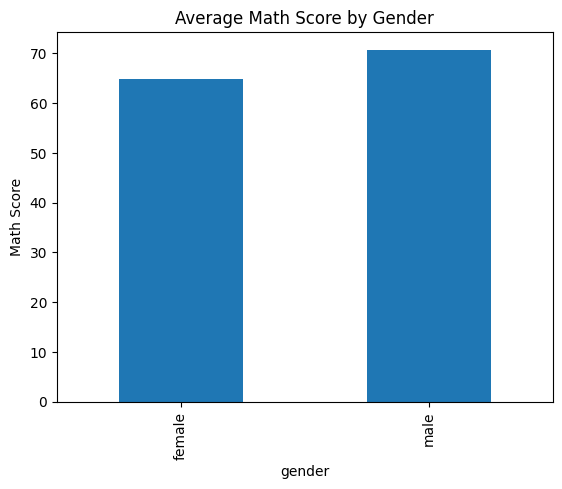

In [38]:
df.groupby('gender')['math score'].mean().plot(kind='bar')

plt.title("Average Math Score by Gender")
plt.ylabel("Math Score")
plt.show()

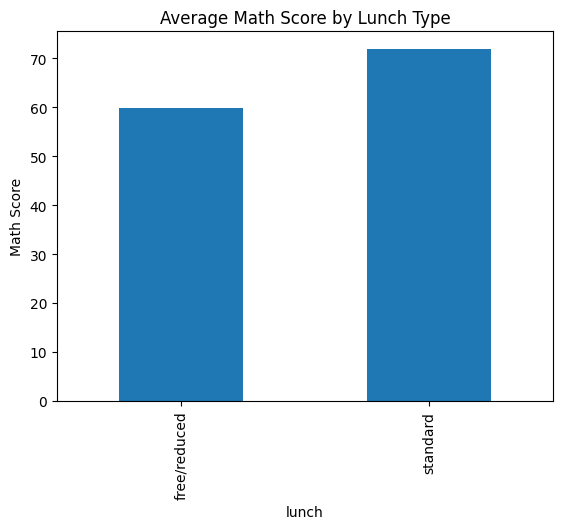

In [39]:
df.groupby('lunch')['math score'].mean().plot(kind='bar')

plt.title("Average Math Score by Lunch Type")
plt.ylabel("Math Score")
plt.show()

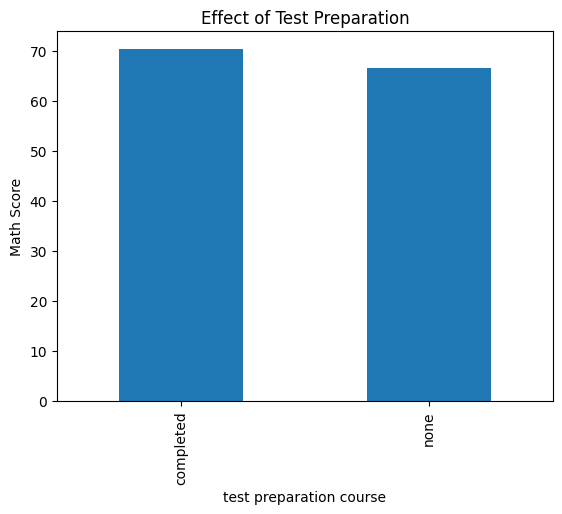

In [40]:
df.groupby('test preparation course')['math score'].mean().plot(kind='bar')

plt.title("Effect of Test Preparation")
plt.ylabel("Math Score")
plt.show()

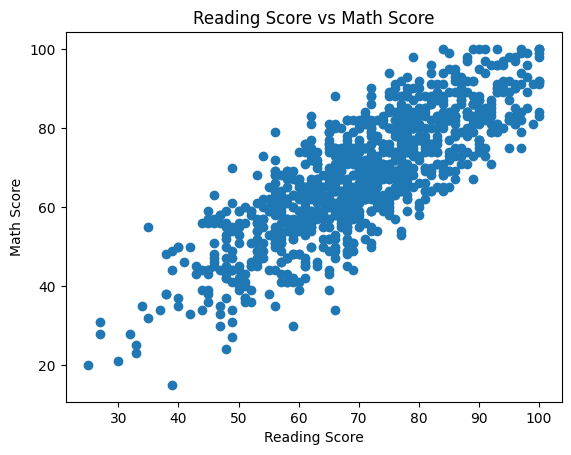

In [41]:
plt.scatter(df['reading score'], df['math score'])

plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.title("Reading Score vs Math Score")

plt.show()

In [42]:
X = df.drop('math score',axis=1)

In [43]:
y = df['math score']

In [44]:

import sklearn
from sklearn.preprocessing import OneHotEncoder


In [45]:
encoder = OneHotEncoder(drop='first', sparse_output=False)

In [46]:
categorical_columns = X.select_dtypes(include='object').columns

In [47]:
print(categorical_columns)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')


In [48]:
encoded = encoder.fit_transform(X[categorical_columns])

In [49]:
print(X)

     gender race/ethnicity parental level of education         lunch  \
0    female        group D                some college      standard   
1      male        group D          associate's degree      standard   
2    female        group D                some college  free/reduced   
3      male        group B                some college  free/reduced   
4    female        group D          associate's degree      standard   
..      ...            ...                         ...           ...   
995    male        group C                some college      standard   
996    male        group C                some college      standard   
997  female        group A                 high school      standard   
998    male        group E                 high school      standard   
999    male        group D                 high school      standard   

    test preparation course  reading score  writing score  
0                 completed             70             78  
1              

In [50]:
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_columns)
)

In [51]:
print(encoded_df)

     gender_male  race/ethnicity_group B  race/ethnicity_group C  \
0            0.0                     0.0                     0.0   
1            1.0                     0.0                     0.0   
2            0.0                     0.0                     0.0   
3            1.0                     1.0                     0.0   
4            0.0                     0.0                     0.0   
..           ...                     ...                     ...   
995          1.0                     0.0                     1.0   
996          1.0                     0.0                     1.0   
997          0.0                     0.0                     0.0   
998          1.0                     0.0                     0.0   
999          1.0                     0.0                     0.0   

     race/ethnicity_group D  race/ethnicity_group E  \
0                       1.0                     0.0   
1                       1.0                     0.0   
2                 

In [52]:
X = X.drop(categorical_columns, axis=1)

In [54]:
X = pd.concat(
    [X.reset_index(drop=True),
     encoded_df.reset_index(drop=True)],
    axis=1
)

In [55]:
print(X.head())

   reading score  writing score  gender_male  race/ethnicity_group B  \
0             70             78          0.0                     0.0   
1             93             87          1.0                     0.0   
2             76             77          0.0                     0.0   
3             70             63          1.0                     1.0   
4             85             86          0.0                     0.0   

   race/ethnicity_group C  race/ethnicity_group D  race/ethnicity_group E  \
0                     0.0                     1.0                     0.0   
1                     0.0                     1.0                     0.0   
2                     0.0                     1.0                     0.0   
3                     0.0                     0.0                     0.0   
4                     0.0                     1.0                     0.0   

   parental level of education_bachelor's degree  \
0                                            0.0   


In [56]:
from sklearn.model_selection import train_test_split

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 14)
(200, 14)
(800,)
(200,)


In [59]:
from sklearn.linear_model import LinearRegression

In [60]:
model = LinearRegression()

In [61]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [62]:
print("Intercept:", model.intercept_)

Intercept: -10.431997834049099


In [63]:
print(model.coef_)

[ 2.69169713e-01  6.73420119e-01  1.28658792e+01  3.58855878e-01
  3.39293810e-01  7.39626401e-02  4.76304137e+00 -6.45653370e-01
 -5.10784666e-02 -5.73941308e-01 -1.12882551e-02 -6.35683230e-01
  4.51912251e+00  3.87536038e+00]


In [64]:
for feature, coef in zip(X_train.columns, model.coef_):
    print(feature, ":", coef)

reading score : 0.2691697134035388
writing score : 0.673420119338604
gender_male : 12.865879177133772
race/ethnicity_group B : 0.35885587761564725
race/ethnicity_group C : 0.3392938095980182
race/ethnicity_group D : 0.07396264010395076
race/ethnicity_group E : 4.763041367535095
parental level of education_bachelor's degree : -0.6456533698532961
parental level of education_high school : -0.051078466614017035
parental level of education_master's degree : -0.5739413076637818
parental level of education_some college : -0.011288255101424473
parental level of education_some high school : -0.6356832300375251
lunch_standard : 4.519122510473816
test preparation course_none : 3.8753603847327707


In [65]:
y_pred = model.predict(X_test)

In [66]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(comparison.head(10))

     Actual  Predicted
521      67  68.184361
737      78  81.306396
740      39  42.646078
660      70  69.310052
411      90  89.600674
678      51  55.516838
626      76  78.622426
513      28  21.251851
859      94  85.649960
136      85  85.637830


In [67]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [68]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

In [69]:
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 4.073537121893529
Mean Squared Error: 24.838558210542573
Root Mean Squared Error: 4.983829673107075
R² Score: 0.8874881345612096
